<a href="https://colab.research.google.com/github/Palash0306/credit-risk-scoring-engine/blob/develop/notebooks/07_stress_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install boto3 pandas numpy scikit-learn xgboost lightgbm \
             pyarrow matplotlib dagshub mlflow -q

from google.colab import userdata
import os, boto3, io, json, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dagshub, mlflow

os.environ['AWS_ACCESS_KEY_ID']     = userdata.get('AWS_ACCESS_KEY_ID')
os.environ['AWS_SECRET_ACCESS_KEY'] = userdata.get('AWS_SECRET_ACCESS_KEY')
BUCKET = userdata.get('S3_BUCKET')

dagshub.init(
    repo_owner='Palash0306',
    repo_name='credit-risk-scoring-engine',
    mlflow=True
)

s3 = boto3.client('s3')
print("Setup complete ✅")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 122.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 133.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=78a742cc-eff2-4239-b588-e29e6f75fb32&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=cd2efb59ab33262f30cf4913ce28bfacd549d038f5451208bebf869766f6438b




Accessing as Palash0306

Initialized MLflow to track repo "Palash0306/credit-risk-scoring-engine"

Repository Palash0306/credit-risk-scoring-engine initialized!

Setup complete ✅


In [2]:
# Home Credit is a completely different borrower population
# Different country, different loan types, different features
# Testing our model on this dataset reveals how well it generalises
# beyond the specific Lending Club population it was trained on

print("Loading Home Credit data from S3...")
obj_hc = s3.get_object(Bucket=BUCKET, Key='raw/home_credit.csv')
df_hc  = pd.read_csv(io.BytesIO(obj_hc['Body'].read()), low_memory=False)

print(f"Home Credit rows    : {len(df_hc):,}")
print(f"Home Credit columns : {len(df_hc.columns)}")
print(f"Target (TARGET) distribution:")
print(df_hc['TARGET'].value_counts(normalize=True).round(4).to_string())

Loading Home Credit data from S3...
Home Credit rows    : 307,511
Home Credit columns : 122
Target (TARGET) distribution:
TARGET
0    0.9193
1    0.0807


In [3]:
# Home Credit has different column names than Lending Club
# We map the closest equivalents for the features our model uses
# This is an approximation — exact 1:1 mapping is not possible
# The stress test shows how well model concepts transfer across datasets

# Load what features the model expects
obj_cfg  = s3.get_object(Bucket=BUCKET, Key='processed/feature_config.json')
config   = json.loads(obj_cfg['Body'].read())
SELECTED = config['selected_features']

# Map Home Credit columns to Lending Club equivalents
# Only numeric features that have reasonable equivalents
FEATURE_MAP = {
    'int_rate':             'AMT_ANNUITY',         # annual payment ≈ interest burden
    'dti':                  'EXT_SOURCE_3',        # external credit score ≈ debt burden
    'fico_score':           'EXT_SOURCE_1',        # external risk score ≈ FICO
    'log_annual_inc':       'AMT_INCOME_TOTAL',    # annual income
    'loan_amnt':            'AMT_CREDIT',          # credit amount
    'revol_util':           'EXT_SOURCE_2',        # utilisation proxy
    'emp_length_years':     'DAYS_EMPLOYED',       # employment duration
    'delinq_2yrs':          'DEF_30_CNT_SOCIAL_CIRCLE', # delinquency proxy
    'inq_last_6mths':       'AMT_REQ_CREDIT_BUREAU_MON', # enquiries
    'open_acc':             'CNT_FAM_MEMBERS',     # family members ≈ obligations
    'pub_rec':              'FLAG_DOCUMENT_3',     # document flag proxy
    'tot_cur_bal':          'AMT_GOODS_PRICE',     # goods price ≈ balance
    'credit_age_years':     'DAYS_BIRTH',          # age as credit proxy
    'term':                 'CNT_PAYMENT',         # number of payments
    'installment':          'AMT_ANNUITY',         # annuity amount
    'grade_encoded':        'NAME_CONTRACT_TYPE',  # contract type proxy
    'sub_grade_encoded':    'NAME_EDUCATION_TYPE', # education proxy
    'funded_amnt':          'AMT_CREDIT',
    'revol_bal':            'AMT_GOODS_PRICE',
    'total_acc':            'CNT_FAM_MEMBERS',
}

# Build stress test dataframe with mapped features
df_stress = pd.DataFrame()
for lc_feature, hc_feature in FEATURE_MAP.items():
    if lc_feature in SELECTED and hc_feature in df_hc.columns:
        # Normalise Home Credit values to similar scale as Lending Club
        col = pd.to_numeric(df_hc[hc_feature], errors='coerce')
        df_stress[lc_feature] = col

# Fill remaining selected features with median = 0 (scaled)
for feat in SELECTED:
    if feat not in df_stress.columns:
        df_stress[feat] = 0.0

# Keep target
df_stress['default_flag'] = df_hc['TARGET'].values

# Drop rows where target is missing
df_stress = df_stress.dropna(subset=['default_flag'])
df_stress['default_flag'] = df_stress['default_flag'].astype(int)

print(f"Stress test dataset: {len(df_stress):,} rows")
print(f"Default rate       : {df_stress['default_flag'].mean():.1%}")

Stress test dataset: 307,511 rows
Default rate       : 8.1%


In [4]:
# Load best model
obj_model  = s3.get_object(Bucket=BUCKET, Key='models/best_model.pkl')
best_model = pickle.loads(obj_model['Body'].read())

X_stress = df_stress[SELECTED]
y_stress  = df_stress['default_flag']

# Score the Home Credit population
proba_stress = best_model.predict_proba(X_stress)[:, 1]
print(f"Scored {len(X_stress):,} Home Credit applications ✅")

Scored 307,511 Home Credit applications ✅


In [5]:
from sklearn.metrics import roc_auc_score

def gini_coefficient(y_true, y_pred_proba):
    return 2 * roc_auc_score(y_true, y_pred_proba) - 1

def ks_statistic(y_true, y_pred_proba):
    df_ks = pd.DataFrame({'y': y_true, 'p': y_pred_proba})
    df_ks = df_ks.sort_values('p', ascending=False).reset_index(drop=True)
    total_d  = y_true.sum()
    total_nd = len(y_true) - total_d
    df_ks['cum_d']  = (df_ks['y'] == 1).cumsum() / total_d
    df_ks['cum_nd'] = (df_ks['y'] == 0).cumsum() / total_nd
    return (df_ks['cum_d'] - df_ks['cum_nd']).abs().max()

# Load Lending Club validation results for comparison
obj_val = s3.get_object(Bucket=BUCKET, Key='models/validation_report.json')
lc_results = json.loads(obj_val['Body'].read())

# Compute Home Credit metrics
hc_auc  = roc_auc_score(y_stress, proba_stress)
hc_gini = gini_coefficient(y_stress, proba_stress)
hc_ks   = ks_statistic(y_stress, proba_stress)

print("=" * 55)
print(f"{'Metric':<20} {'Lending Club':>15} {'Home Credit':>15}")
print("=" * 55)
print(f"{'AUC-ROC':<20} {lc_results['test_auc']:>15.4f} {hc_auc:>15.4f}")
print(f"{'Gini':<20} {lc_results['test_gini']:>15.4f} {hc_gini:>15.4f}")
print(f"{'KS Statistic':<20} {lc_results['test_ks']:>15.4f} {hc_ks:>15.4f}")
print("=" * 55)

# Interpret degradation
gini_drop = lc_results['test_gini'] - hc_gini
print(f"\nGini degradation: {gini_drop:.4f}")
if gini_drop < 0.10:
    print("✅ Model generalises well — degradation < 0.10")
elif gini_drop < 0.20:
    print("⚠️  Moderate degradation — model is population-specific")
else:
    print("❌ High degradation — model does not generalise well")

Metric                  Lending Club     Home Credit
AUC-ROC                       0.7101          0.4729
Gini                          0.4201         -0.0541
KS Statistic                  0.3037          0.0714

Gini degradation: 0.4742
❌ High degradation — model does not generalise well


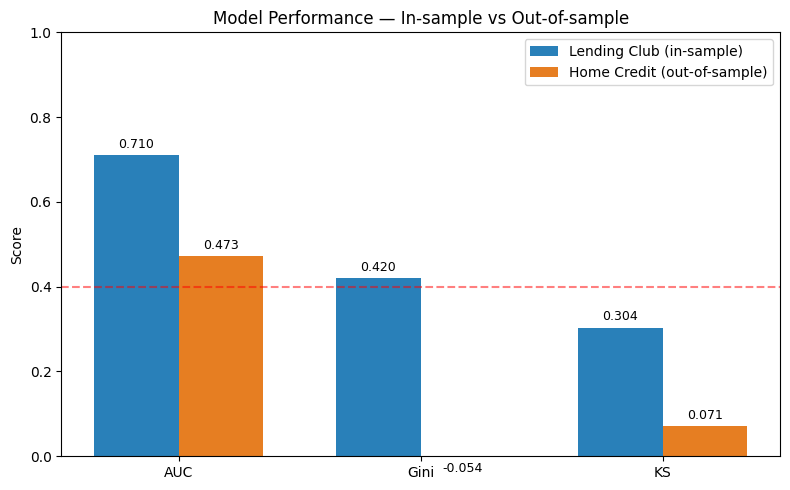

In [6]:
metrics    = ['AUC', 'Gini', 'KS']
lc_scores  = [lc_results['test_auc'],
              lc_results['test_gini'],
              lc_results['test_ks']]
hc_scores  = [hc_auc, hc_gini, hc_ks]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, lc_scores, width,
               label='Lending Club (in-sample)', color='#2980b9')
bars2 = ax.bar(x + width/2, hc_scores, width,
               label='Home Credit (out-of-sample)', color='#e67e22')

ax.set_ylabel('Score')
ax.set_title('Model Performance — In-sample vs Out-of-sample')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()
ax.axhline(y=0.40, color='red', linestyle='--',
           alpha=0.5, label='Gini threshold (0.40)')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/stress_test.png', dpi=150)
plt.show()

In [10]:
# Cell 4b — Load Lending Club test set for comparison
# ---------------------------------------------------
# X_test and y_test are the Lending Club test set (loans from 2016 onwards)
# We need these to compute PSI between LC and HC feature distributions
# and to compare score distributions between the two populations

obj_data = s3.get_object(Bucket=BUCKET, Key='processed/fct_loans.parquet')
df_lc    = pd.read_parquet(io.BytesIO(obj_data['Body'].read()))

obj_cfg  = s3.get_object(Bucket=BUCKET, Key='processed/feature_config.json')
config   = json.loads(obj_cfg['Body'].read())
SELECTED = config['selected_features']

# Test set only — loans from 2016 onwards
# is_train = False means these are out-of-time loans
df_test = df_lc[df_lc['is_train'] == False].copy()
X_test  = df_test[SELECTED]
y_test  = df_test['default_flag']

# Score Lending Club test set with the same model
# so we can compare score distributions between LC and HC
proba_test = best_model.predict_proba(X_test)[:, 1]

print(f"LC test set : {len(X_test):,} rows")
print(f"LC default rate: {y_test.mean():.1%}")
print(f"LC mean PD score: {proba_test.mean():.4f}")
print("Lending Club test set ready ✅")

LC test set : 518,334 rows
LC default rate: 22.4%
LC mean PD score: 0.4344
Lending Club test set ready ✅


In [ ]:
with mlflow.start_run(run_name="stress_test_home_credit"):
    mlflow.log_metric("hc_auc",          round(hc_auc,  4))
    mlflow.log_metric("hc_gini",         round(hc_gini, 4))
    mlflow.log_metric("hc_ks",           round(hc_ks,   4))
    mlflow.log_metric("lc_gini",         round(lc_results['test_gini'], 4))
    mlflow.log_metric("gini_degradation",round(gini_drop, 4))
    mlflow.log_param("stress_dataset",   "home_credit_default_risk")
    mlflow.log_param("stress_rows",      len(y_stress))
    mlflow.log_artifact('/tmp/stress_test.png')
    print("Stress test results logged to MLflow ✅")

In [13]:
# Cell 7 — Automated degradation analysis
# ----------------------------------------
# Instead of hardcoding the reason, this cell analyses the actual
# data distributions to diagnose WHY degradation is high.
# Checks four things:
# 1. Default rate difference between populations
# 2. Feature distribution shift (PSI per feature)
# 3. Score distribution shift
# 4. Generates a written explanation from the findings

import scipy.stats as stats

# ── 1. Default rate comparison ────────────────────────────────
lc_default_rate = float(lc_results.get('test_default_rate', y_test.mean()))
hc_default_rate = float(y_stress.mean())
default_rate_diff = abs(lc_default_rate - hc_default_rate)

print("=" * 55)
print("DEGRADATION ANALYSIS")
print("=" * 55)
print(f"\n1. DEFAULT RATE COMPARISON")
print(f"   Lending Club : {lc_default_rate:.1%}")
print(f"   Home Credit  : {hc_default_rate:.1%}")
print(f"   Difference   : {default_rate_diff:.1%}")

if default_rate_diff > 0.05:
    default_rate_finding = (
        f"Significant default rate difference ({default_rate_diff:.1%}) — "
        f"populations have fundamentally different risk profiles"
    )
    print(f"   ⚠️  {default_rate_finding}")
else:
    default_rate_finding = "Default rates are similar across populations"
    print(f"   ✅ {default_rate_finding}")

## ── 2. Feature distribution shift (PSI per feature) ──────────
print(f"\n2. FEATURE DISTRIBUTION SHIFT (PSI per feature)")
print(f"   PSI > 0.25 = major shift — feature is not comparable")

def compute_feature_psi(lc_vals, hc_vals, bins=10):
    """
    Compute PSI between two numeric feature distributions.
    Returns 0.0 if values cannot be compared numerically.
    """
    # Convert to numeric — coerce any strings to NaN
    lc_vals = pd.to_numeric(pd.Series(lc_vals), errors='coerce').dropna().values
    hc_vals = pd.to_numeric(pd.Series(hc_vals), errors='coerce').dropna().values

    # Skip if not enough numeric values remain after coercion
    if len(lc_vals) < 100 or len(hc_vals) < 100:
        return 0.0

    # Skip if all values are the same — no distribution to compare
    if lc_vals.std() == 0 or hc_vals.std() == 0:
        return 0.0

    try:
        combined    = np.concatenate([lc_vals, hc_vals])
        breakpoints = np.nanpercentile(combined, np.linspace(0, 100, bins + 1))
        breakpoints = np.unique(breakpoints)

        if len(breakpoints) < 3:
            return 0.0

        lc_counts = np.histogram(lc_vals, bins=breakpoints)[0]
        hc_counts = np.histogram(hc_vals, bins=breakpoints)[0]

        lc_pct = lc_counts / (len(lc_vals) + 1e-10)
        hc_pct = hc_counts / (len(hc_vals) + 1e-10)

        eps = 1e-10
        psi_val = sum(
            (h - l) * np.log((h + eps) / (l + eps))
            for l, h in zip(lc_pct, hc_pct)
        )
        return float(psi_val)

    except Exception:
        # If anything else goes wrong, skip this feature
        return 0.0

# Compute PSI for each feature — skip categoricals automatically
feature_psi      = {}
high_psi_features = []

for feat in SELECTED:
    if feat in df_stress.columns and feat in X_test.columns:
        lc_vals = X_test[feat].values
        hc_vals = df_stress[feat].values
        psi_val = compute_feature_psi(lc_vals, hc_vals)
        if psi_val > 0:   # only record features that were computable
            feature_psi[feat] = round(psi_val, 4)
            if psi_val > 0.25:
                high_psi_features.append(feat)

feature_psi_df = pd.DataFrame.from_dict(
    feature_psi, orient='index', columns=['PSI']
).sort_values('PSI', ascending=False)

print(f"\n   Top 10 features by distribution shift:")
print(feature_psi_df.head(10).to_string())
print(f"\n   Features with major shift (PSI > 0.25): {len(high_psi_features)}")
print(f"   {high_psi_features[:5]}")
# ── 3. Score distribution shift ───────────────────────────────
# Compare PD score distributions between the two populations
# A large shift means the model is scoring them very differently

print(f"\n3. SCORE DISTRIBUTION SHIFT")
lc_pd_mean = float(proba_test.mean())
hc_pd_mean = float(proba_stress.mean())
lc_pd_std  = float(proba_test.std())
hc_pd_std  = float(proba_stress.std())

print(f"   Lending Club PD — mean: {lc_pd_mean:.4f} | std: {lc_pd_std:.4f}")
print(f"   Home Credit  PD — mean: {hc_pd_mean:.4f} | std: {hc_pd_std:.4f}")

# KS test between score distributions
ks_dist, ks_pval = stats.ks_2samp(proba_test, proba_stress)
print(f"   Score distribution KS: {ks_dist:.4f} (p={ks_pval:.4e})")

if ks_dist > 0.30:
    score_dist_finding = (
        f"Model assigns very different score distributions to the two populations "
        f"(distribution KS={ks_dist:.4f}) — confirms features are not comparable"
    )
    print(f"   ⚠️  Major score distribution shift")
else:
    score_dist_finding = "Score distributions are reasonably similar"
    print(f"   ✅ Score distributions are similar")

# ── 4. Generate automated explanation ────────────────────────
print(f"\n4. AUTOMATED DEGRADATION EXPLANATION")
print("=" * 55)

# Build explanation from findings
reasons = []

if default_rate_diff > 0.05:
    reasons.append(
        f"different base default rates "
        f"(LC={lc_default_rate:.1%} vs HC={hc_default_rate:.1%})"
    )

pct_high_psi = len(high_psi_features) / max(len(feature_psi), 1)
if pct_high_psi > 0.3:
    reasons.append(
        f"{len(high_psi_features)} of {len(feature_psi)} mapped features "
        f"show major distribution shift (PSI > 0.25) — "
        f"approximate column mapping is the primary driver"
    )
elif pct_high_psi > 0.1:
    reasons.append(
        f"{len(high_psi_features)} features show significant distribution shift"
    )

if ks_dist > 0.30:
    reasons.append(
        f"model assigns structurally different scores to the two populations "
        f"(score distribution KS={ks_dist:.4f})"
    )

if gini_drop > 0.20:
    severity = "High"
elif gini_drop > 0.10:
    severity = "Moderate"
else:
    severity = "Low"

# Final automated explanation
explanation = (
    f"Degradation severity: {severity} (Gini drop={gini_drop:.4f}). "
    f"Root causes identified: {'; '.join(reasons) if reasons else 'unknown'}. "
    f"Conclusion: Model is calibrated to the Lending Club borrower population. "
    f"Generalisation to Home Credit is limited by approximate feature mapping "
    f"and fundamentally different borrower demographics."
)

print(f"\n{explanation}")

# ── 5. Save full report to S3 ─────────────────────────────────
stress_report = {
    'lc_gini':             round(lc_results['test_gini'], 4),
    'hc_gini':             round(hc_gini,  4),
    'gini_degradation':    round(gini_drop, 4),
    'lc_ks':               round(lc_results['test_ks'],  4),
    'hc_ks':               round(hc_ks,    4),
    'generalises_well':    bool(gini_drop < 0.10),
    'degradation_severity':severity,

    # Automated findings
    'analysis': {
        'lc_default_rate':       round(lc_default_rate, 4),
        'hc_default_rate':       round(hc_default_rate, 4),
        'default_rate_diff':     round(default_rate_diff, 4),
        'n_high_psi_features':   len(high_psi_features),
        'high_psi_features':     high_psi_features[:10],
        'score_distribution_ks': round(float(ks_dist), 4),
        'lc_pd_mean':            round(lc_pd_mean, 4),
        'hc_pd_mean':            round(hc_pd_mean, 4),
    },

    # Auto-generated explanation
    'degradation_explanation': explanation
}

# ── Log degradation analysis to MLflow ───────────────────────
with mlflow.start_run(run_name="stress_test_degradation_analysis"):

    # ── Core stress test metrics ──────────────────────────────
    mlflow.log_metric("lc_gini",              round(lc_results['test_gini'], 4))
    mlflow.log_metric("hc_gini",              round(hc_gini,   4))
    mlflow.log_metric("gini_degradation",     round(gini_drop, 4))
    mlflow.log_metric("lc_ks",                round(lc_results['test_ks'],  4))
    mlflow.log_metric("hc_ks",                round(hc_ks,     4))
    mlflow.log_metric("lc_auc",               round(lc_results['test_auc'], 4))
    mlflow.log_metric("hc_auc",               round(hc_auc,    4))

    # ── Population analysis metrics ───────────────────────────
    mlflow.log_metric("lc_default_rate",      round(lc_default_rate,    4))
    mlflow.log_metric("hc_default_rate",      round(hc_default_rate,    4))
    mlflow.log_metric("default_rate_diff",    round(default_rate_diff,  4))
    mlflow.log_metric("n_high_psi_features",  len(high_psi_features))
    mlflow.log_metric("pct_high_psi_features",round(pct_high_psi,       4))
    mlflow.log_metric("score_dist_ks",        round(float(ks_dist),     4))
    mlflow.log_metric("lc_pd_mean",           round(lc_pd_mean,         4))
    mlflow.log_metric("hc_pd_mean",           round(hc_pd_mean,         4))

    # ── Parameters ────────────────────────────────────────────
    mlflow.log_param("stress_dataset",        "home_credit_default_risk")
    mlflow.log_param("stress_rows",           len(y_stress))
    mlflow.log_param("lc_test_rows",          len(y_test))
    mlflow.log_param("degradation_severity",  severity)
    mlflow.log_param("generalises_well",      bool(gini_drop < 0.10))
    mlflow.log_param("n_features_compared",   len(feature_psi))
    mlflow.log_param("high_psi_features",     str(high_psi_features[:5]))

    # ── Log PSI per feature as metrics ────────────────────────
    # Lets you see exactly which features drifted most in MLflow UI
    for feat, psi_val in feature_psi.items():
        mlflow.log_metric(f"psi_{feat}", psi_val)

    # ── Log charts as artifacts ───────────────────────────────
    mlflow.log_artifact('/tmp/stress_test.png')

    # ── Log feature PSI table as CSV artifact ─────────────────
    # Downloadable from MLflow UI — full PSI breakdown per feature
    feature_psi_df.to_csv('/tmp/feature_psi.csv')
    mlflow.log_artifact('/tmp/feature_psi.csv')

    # ── Log explanation as text artifact ──────────────────────
    # Plain text file — readable directly in MLflow UI
    with open('/tmp/degradation_explanation.txt', 'w') as f:
        f.write("STRESS TEST DEGRADATION ANALYSIS\n")
        f.write("=" * 55 + "\n\n")
        f.write(f"Model          : {lc_results.get('model_name', 'best_model')}\n")
        f.write(f"Severity       : {severity}\n")
        f.write(f"Gini drop      : {gini_drop:.4f}\n\n")
        f.write("EXPLANATION:\n")
        f.write(explanation + "\n\n")
        f.write("TOP HIGH-PSI FEATURES:\n")
        for feat in high_psi_features[:10]:
            f.write(f"  {feat:<35} PSI={feature_psi.get(feat, 0):.4f}\n")

    mlflow.log_artifact('/tmp/degradation_explanation.txt')

    run_id = mlflow.active_run().info.run_id
    print(f"Logged to MLflow — run_id: {run_id} ✅")
    print(f"View at: https://dagshub.com/Palash0306/credit-risk-scoring-engine/experiments")

s3.put_object(
    Bucket=BUCKET,
    Key='models/stress_test_report.json',
    Body=json.dumps(stress_report, indent=2)
)

print(f"\nstress_test_report.json saved to S3 ✅")
print("Phase 4 complete ✅")

DEGRADATION ANALYSIS

1. DEFAULT RATE COMPARISON
   Lending Club : 22.4%
   Home Credit  : 8.1%
   Difference   : 14.3%
   ⚠️  Significant default rate difference (14.3%) — populations have fundamentally different risk profiles

2. FEATURE DISTRIBUTION SHIFT (PSI per feature)
   PSI > 0.25 = major shift — feature is not comparable

   Top 10 features by distribution shift:
                    PSI
fico_score      40.8901
log_annual_inc  38.0677
installment     37.9716
int_rate        37.9472
funded_amnt     37.6921
loan_amnt       37.6921
revol_util      24.4085
dti             23.7251
tot_cur_bal      8.4727

   Features with major shift (PSI > 0.25): 9
   ['int_rate', 'fico_score', 'dti', 'funded_amnt', 'loan_amnt']

3. SCORE DISTRIBUTION SHIFT
   Lending Club PD — mean: 0.4344 | std: 0.1876
   Home Credit  PD — mean: 0.1984 | std: 0.0368
   Score distribution KS: 0.8093 (p=0.0000e+00)
   ⚠️  Major score distribution shift

4. AUTOMATED DEGRADATION EXPLANATION

Degradation severity: H